# 04 — Xây dựng & đánh giá 3 mô hình dự báo Churn (Logistic / Random Forest / XGBoost)

**Task T14** · Owner: Đào · Lan review · Phục vụ mục **3.2** (đặc trưng), **3.4** (huấn luyện) và
**3.5** (đánh giá, so sánh, chọn mô hình).

**Dữ liệu:** log giao dịch thật của nhóm (`bnpl_transactions_clean.csv`, `bnpl_customers_clean.csv`) —
KHÔNG dùng trực tiếp `bnpl_customer_features.csv`, vì file đó tổng hợp đặc trưng trên **toàn bộ** cửa sổ
quan sát (kể cả giai đoạn dùng để tính nhãn), nên `recency_days` trong đó đồng nhất về mặt toán học với
nhãn `churn_60d` (churn = recency_days ≥ 60) → đưa thẳng vào làm feature là **rò rỉ nhãn hoàn toàn**,
model sẽ đạt AUC ≈ 1.0 một cách vô nghĩa. Notebook này **tính lại đặc trưng từ log giao dịch gốc**, chỉ
dùng dữ liệu tính đến một mốc tham chiếu `T_ref`, và gán nhãn từ cửa sổ **sau** `T_ref` — đúng chuẩn
chống rò rỉ dữ liệu (time-based split).

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, precision_score,
                             recall_score, accuracy_score, RocCurveDisplay, ConfusionMatrixDisplay,
                             precision_recall_curve, classification_report)
from xgboost import XGBClassifier

plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

BASE_DIR = "/content/drive/MyDrive/ChuyenDe_BNPL_Churn"
DATA_DIR = f"{BASE_DIR}/data"
REPORTS_DIR = f"{BASE_DIR}/reports"
FIG_DIR = f"{REPORTS_DIR}/figures"
MODELS_DIR = f"{BASE_DIR}/models"
for d in (FIG_DIR, MODELS_DIR):
    os.makedirs(d, exist_ok=True)

# (Nếu mục 2 đã load sẵn tx/cust, có thể bỏ 2 dòng dưới — giữ lại để mục 4 chạy độc lập được)
tx = pd.read_csv(f"{DATA_DIR}/bnpl_transactions_clean.csv", parse_dates=["transaction_date"])
cust = pd.read_csv(f"{DATA_DIR}/bnpl_customers_clean.csv", parse_dates=["activation_date"])

OBS_DATE = pd.Timestamp("2024-12-30")
CHURN_WINDOW_DAYS = 60          # đúng định nghĩa đã chốt ở T02
T_ref = OBS_DATE - pd.Timedelta(days=CHURN_WINDOW_DAYS)

print(f"Giao dịch: {len(tx):,} | Khách đăng ký: {len(cust):,}")
print(f"OBS_DATE = {OBS_DATE:%d/%m/%Y} | T_ref = {T_ref:%d/%m/%Y} (mốc tính đặc trưng)")
print(f"Cửa sổ nhãn: ({T_ref:%d/%m/%Y}, {OBS_DATE:%d/%m/%Y}] — {CHURN_WINDOW_DAYS} ngày")

Giao dịch: 64,746 | Khách đăng ký: 8,000
OBS_DATE = 30/12/2024 | T_ref = 31/10/2024 (mốc tính đặc trưng)
Cửa sổ nhãn: (31/10/2024, 30/12/2024] — 60 ngày


## 1. Gán nhãn Churn không rò rỉ (mục 3.1.2)

- **Cửa sổ đặc trưng**: mọi giao dịch **đến `T_ref`** → dùng để tính đặc trưng hành vi.
- **Cửa sổ nhãn**: `(T_ref, OBS_DATE]` — khách **không có** giao dịch nào trong cửa sổ này ⇒ `churn = 1`.
- **Tập mô hình hóa**: chỉ gồm khách đã có **ít nhất 1 giao dịch trước `T_ref`** — khách hoàn toàn chưa
  từng giao dịch (nhóm "kích hoạt hụt", đã phân tích riêng ở T13) không thuộc phạm vi bài toán dự báo
  churn hành vi này.

In [2]:
hist = tx[tx.transaction_date <= T_ref].copy()
future = tx[(tx.transaction_date > T_ref) & (tx.transaction_date <= OBS_DATE)]
active_future = set(future.customer_id.unique())

pop_ids = hist.customer_id.unique()
print(f"Khách có giao dịch trước T_ref (population mô hình): {len(pop_ids):,}")

y_map = pd.Series(~np.isin(pop_ids, list(active_future)), index=pop_ids).astype(int)
print(f"Churn rate trên population này: {y_map.mean():.2%} ({y_map.sum():,}/{len(y_map):,})")
print("→ Khớp sát với churn_60d gốc (17,6–18,3% tùy population) — xác nhận cách gán nhãn nhất quán với T02.")

Khách có giao dịch trước T_ref (population mô hình): 6,761


Churn rate trên population này: 17.97% (1,215/6,761)
→ Khớp sát với churn_60d gốc (17,6–18,3% tùy population) — xác nhận cách gán nhãn nhất quán với T02.


## 2. Trích xuất đặc trưng — chỉ từ dữ liệu tính đến `T_ref` (mục 3.2.2)

Ba nhóm đặc trưng:
1. **RFM mở rộng** từ lịch sử giao dịch (`hist`) — Recency/Frequency/Monetary tại `T_ref`.
2. **Hành vi thanh toán**: tỷ lệ trễ hạn, tỷ lệ dùng khuyến mãi, đa dạng danh mục.
3. **Đặc trưng tĩnh** từ hồ sơ khách hàng (`cust`) — nhân khẩu học, hạn mức, kênh giới thiệu.

Toàn bộ đều **tính tại thời điểm `T_ref`**, không dùng bất kỳ thông tin nào sau mốc này.

In [3]:
def build_features(hist: pd.DataFrame, t_ref: pd.Timestamp) -> pd.DataFrame:
    g = hist.sort_values("transaction_date").groupby("customer_id")
    f = pd.DataFrame(index=g.size().index)

    last, first = g["transaction_date"].max(), g["transaction_date"].min()
    f["recency_days"]  = (t_ref - last).dt.days
    f["tenure_days"]   = (t_ref - first).dt.days
    f["freq_total"]    = g.size()
    for w in (30, 90, 180):
        f[f"freq_{w}d"] = (hist[hist.transaction_date > t_ref - pd.Timedelta(days=w)]
                          .groupby("customer_id").size())
    f["monetary_90d"]   = (hist[hist.transaction_date > t_ref - pd.Timedelta(days=90)]
                          .groupby("customer_id")["amount_vnd"].sum())
    f["monetary_total"] = g["amount_vnd"].sum()
    f["aov"]            = g["amount_vnd"].mean()
    f["amount_std"]     = g["amount_vnd"].std()
    f["unique_categories"] = g["payment_category"].nunique()
    f["txn_per_month"]  = f["freq_total"] / (f["tenure_days"] / 30).clip(lower=1)
    f["mean_inter_days"] = g["transaction_date"].apply(lambda s: s.diff().dt.days.mean())
    f["top_category"]  = g["payment_category"].agg(lambda s: s.mode().iloc[0])

    # Hành vi thanh toán & khuyến mãi
    f["late_rate"]     = g["repayment_status"].apply(lambda s: (s == "Late").mean())
    f["partial_rate"]  = g["repayment_status"].apply(lambda s: (s == "Partial").mean())
    f["promo_rate"]    = g["promo_applied"].apply(lambda s: (s != "No Promo").mean())
    f["suspicious_count"] = g["is_suspicious_flag"].sum()
    return f

feat = build_features(hist, T_ref)
for c in ["freq_30d", "freq_90d", "freq_180d", "monetary_90d"]:
    feat[c] = feat[c].fillna(0)
feat["amount_std"] = feat["amount_std"].fillna(0)
feat["mean_inter_days"] = feat["mean_inter_days"].fillna(feat["tenure_days"])

# Ghép đặc trưng tĩnh từ hồ sơ khách hàng
static_cols = ["age", "gender", "city_tier", "kyc_verified", "phone_verified",
              "device_type", "referral_source", "credit_limit_vnd"]
feat = feat.join(cust.set_index("customer_id")[static_cols])
feat["account_age_days"] = (T_ref - cust.set_index("customer_id").loc[feat.index, "activation_date"]).dt.days

feat["churn"] = y_map.reindex(feat.index)
print(f"Ma trận đặc trưng: {feat.shape} | Churn rate: {feat['churn'].mean():.2%}")
feat.head(3)

Ma trận đặc trưng: (6761, 28) | Churn rate: 17.97%


,recency_days,tenure_days,freq_total,freq_30d,freq_90d,freq_180d,monetary_90d,monetary_total,aov,amount_std,...,age,gender,city_tier,kyc_verified,phone_verified,device_type,referral_source,credit_limit_vnd,account_age_days,churn
customer_id,,,,,,,,,,,,,,,,,,,,,
ZLP000002,30,297,9,0.0,2.0,6.0,1020000.0,3328000.0,3.697778e+05,144970.495082,...,27.0,Male,1,1,1,iOS,Organic,1000000,364,0
ZLP000003,83,148,3,0.0,1.0,3.0,798000.0,1990000.0,6.633333e+05,273148.921531,...,31.0,Female,3,1,1,Android,Campaign,2000000,154,0
ZLP000005,47,297,5,0.0,1.0,2.0,2710000.0,10596000.0,2.119200e+06,810203.492957,...,26.0,Female,1,1,1,iOS,Organic,2000000,334,0


In [4]:
# Lưu ma trận đặc trưng đầy đủ để notebook T15 (Feature Importance & Model Selection)
# tái tạo đúng train/test split và làm SHAP mà không phải chép lại logic feature engineering.
feat.to_csv(f"{DATA_DIR}/bnpl_model_features.csv", index_label="customer_id")
print("Đã lưu ../data/bnpl_model_features.csv cho notebook 05 (T15).")

Đã lưu ../data/bnpl_model_features.csv cho notebook 05 (T15).


In [5]:
data_dict = {
    "recency_days": "Số ngày từ giao dịch gần nhất đến T_ref",
    "tenure_days": "Số ngày từ giao dịch đầu tiên đến T_ref",
    "freq_total": "Tổng số giao dịch trước T_ref",
    "freq_30d/90d/180d": "Số giao dịch trong 30/90/180 ngày trước T_ref",
    "monetary_90d": "Tổng chi tiêu 90 ngày trước T_ref",
    "monetary_total": "Tổng chi tiêu toàn kỳ trước T_ref",
    "aov": "Giá trị giao dịch trung bình", "amount_std": "Độ lệch chuẩn giá trị giao dịch",
    "unique_categories": "Số danh mục thanh toán từng dùng",
    "txn_per_month": "Số giao dịch trung bình mỗi tháng",
    "mean_inter_days": "Khoảng cách trung bình giữa 2 giao dịch liên tiếp (ngày)",
    "top_category": "Danh mục thanh toán dùng nhiều nhất (one-hot)",
    "late_rate": "Tỷ lệ giao dịch trả trễ hạn", "partial_rate": "Tỷ lệ giao dịch trả một phần",
    "promo_rate": "Tỷ lệ giao dịch có áp dụng khuyến mãi",
    "suspicious_count": "Số giao dịch bị gắn cờ nghi ngờ",
    "age/gender/city_tier/...": "Đặc trưng tĩnh từ hồ sơ khách hàng",
    "account_age_days": "Số ngày từ khi kích hoạt tài khoản đến T_ref",
    "churn": f"1 nếu KHÔNG có giao dịch trong {CHURN_WINDOW_DAYS} ngày sau T_ref",
}
pd.Series(data_dict, name="Mô tả").to_frame()

,Mô tả
recency_days,Số ngày từ giao dịch gần nhất đến T_ref
tenure_days,Số ngày từ giao dịch đầu tiên đến T_ref
freq_total,Tổng số giao dịch trước T_ref
freq_30d/90d/180d,Số giao dịch trong 30/90/180 ngày trước T_ref
monetary_90d,Tổng chi tiêu 90 ngày trước T_ref
monetary_total,Tổng chi tiêu toàn kỳ trước T_ref
aov,Giá trị giao dịch trung bình
amount_std,Độ lệch chuẩn giá trị giao dịch
unique_categories,Số danh mục thanh toán từng dùng
txn_per_month,Số giao dịch trung bình mỗi tháng


## 3. Chia Train/Test & thiết lập pipeline tiền xử lý (mục 3.4.1)
- Chia **80/20, stratified** để giữ nguyên tỷ lệ churn ở cả hai tập.
- Impute + chuẩn hóa/encode đặt **trong pipeline**, fit trên train — không rò rỉ thông tin từ test.
- Mất cân bằng lớp xử lý bằng `class_weight="balanced"` (LR, RF) / `scale_pos_weight` (XGBoost) —
  **không dùng SMOTE**, đúng quyết định đã chốt trong mục lục v2 và Chương 2.

In [6]:
num_cols = ["recency_days", "tenure_days", "freq_total", "freq_30d", "freq_90d", "freq_180d",
           "monetary_90d", "monetary_total", "aov", "amount_std", "unique_categories",
           "txn_per_month", "mean_inter_days", "late_rate", "partial_rate", "promo_rate",
           "suspicious_count", "age", "city_tier", "kyc_verified", "phone_verified",
           "credit_limit_vnd", "account_age_days"]
cat_cols = ["top_category", "gender", "device_type", "referral_source"]

X = feat[num_cols + cat_cols]
y = feat["churn"].astype(int)

def make_pre():
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num_cols),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
    ])

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
spw = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f"Train: {X_tr.shape} | Test: {X_te.shape} | churn train: {y_tr.mean():.2%} | scale_pos_weight = {spw:.2f}")

models = {
    "Logistic Regression": Pipeline([("pre", make_pre()),
        ("clf", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE))]),
    "Random Forest": Pipeline([("pre", make_pre()),
        ("clf", RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight="balanced",
                                       n_jobs=-1, random_state=RANDOM_STATE))]),
    "XGBoost": Pipeline([("pre", make_pre()),
        ("clf", XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.8,
                              colsample_bytree=0.8, scale_pos_weight=spw, eval_metric="logloss",
                              tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE))]),
}

Train: (5408, 27) | Test: (1353, 27) | churn train: 17.97% | scale_pos_weight = 4.56


## 4. Cross-validation 5-fold trên tập train (mục 3.4.2)

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_table = pd.DataFrame([
    {"Model": name,
     "CV AUC (mean)": (s := cross_val_score(m, X_tr, y_tr, cv=cv, scoring="roc_auc", n_jobs=-1)).mean(),
     "CV AUC (std)": s.std()}
    for name, m in models.items()
]).set_index("Model").round(4)
cv_table

,CV AUC (mean),CV AUC (std)
Model,,
Logistic Regression,0.9309,0.0115
Random Forest,0.9561,0.0064
XGBoost,0.9530,0.0066


## 5. Đánh giá trên tập test (mục 3.5.1)

In [8]:
rows, fitted = [], {}
for name, m in models.items():
    m.fit(X_tr, y_tr)
    fitted[name] = m
    proba = m.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    rows.append({"Model": name, "AUC": roc_auc_score(y_te, proba),
                 "PR-AUC": average_precision_score(y_te, proba),
                 "F1 (churn)": f1_score(y_te, pred), "Precision": precision_score(y_te, pred),
                 "Recall": recall_score(y_te, pred), "Accuracy": accuracy_score(y_te, pred)})
results = pd.DataFrame(rows).set_index("Model").round(4)
results.to_csv(f"{REPORTS_DIR}/model_comparison_bnpl.csv")
results

,AUC,PR-AUC,F1 (churn),Precision,Recall,Accuracy
Model,,,,,,
Logistic Regression,0.9374,0.8265,0.6594,0.5315,0.8683,0.8389
Random Forest,0.9590,0.8787,0.7724,0.7839,0.7613,0.9194
XGBoost,0.9573,0.8749,0.7629,0.7645,0.7613,0.9150


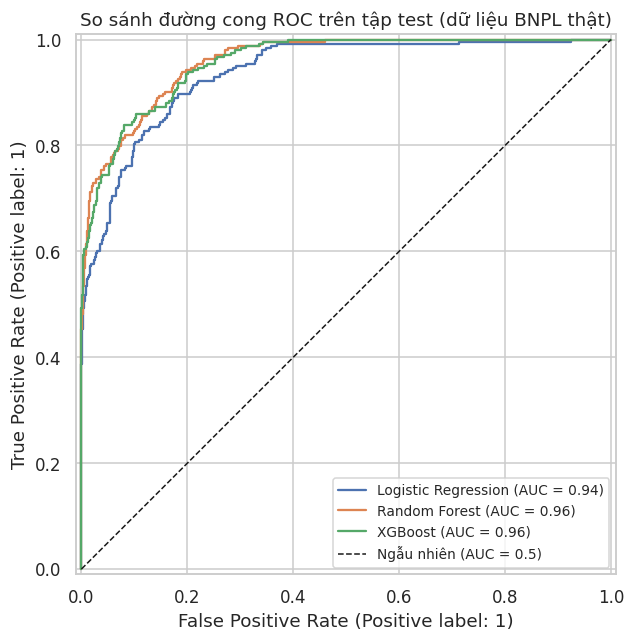

Mô hình tốt nhất theo AUC: Random Forest

                 precision    recall  f1-score   support

Không churn (0)       0.95      0.95      0.95      1110
      Churn (1)       0.78      0.76      0.77       243

       accuracy                           0.92      1353
      macro avg       0.87      0.86      0.86      1353
   weighted avg       0.92      0.92      0.92      1353



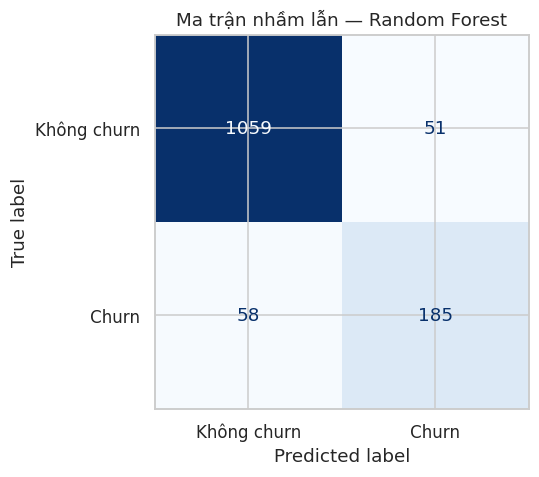

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, m in fitted.items():
    RocCurveDisplay.from_estimator(m, X_te, y_te, ax=ax, name=name)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Ngẫu nhiên (AUC = 0.5)")
ax.set_title("So sánh đường cong ROC trên tập test (dữ liệu BNPL thật)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/bnpl_roc_comparison.png", bbox_inches="tight"); plt.show()

best_name = results["AUC"].idxmax()
best_model = fitted[best_name]
print(f"Mô hình tốt nhất theo AUC: {best_name}\n")
print(classification_report(y_te, best_model.predict(X_te), target_names=["Không churn (0)", "Churn (1)"]))

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_estimator(best_model, X_te, y_te, display_labels=["Không churn", "Churn"],
                                      cmap="Blues", colorbar=False, ax=ax)
ax.set_title(f"Ma trận nhầm lẫn — {best_name}")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/bnpl_confusion_matrix.png", bbox_inches="tight"); plt.show()

## 6. Tầm quan trọng đặc trưng (mục 3.5.2, đầu vào T15)

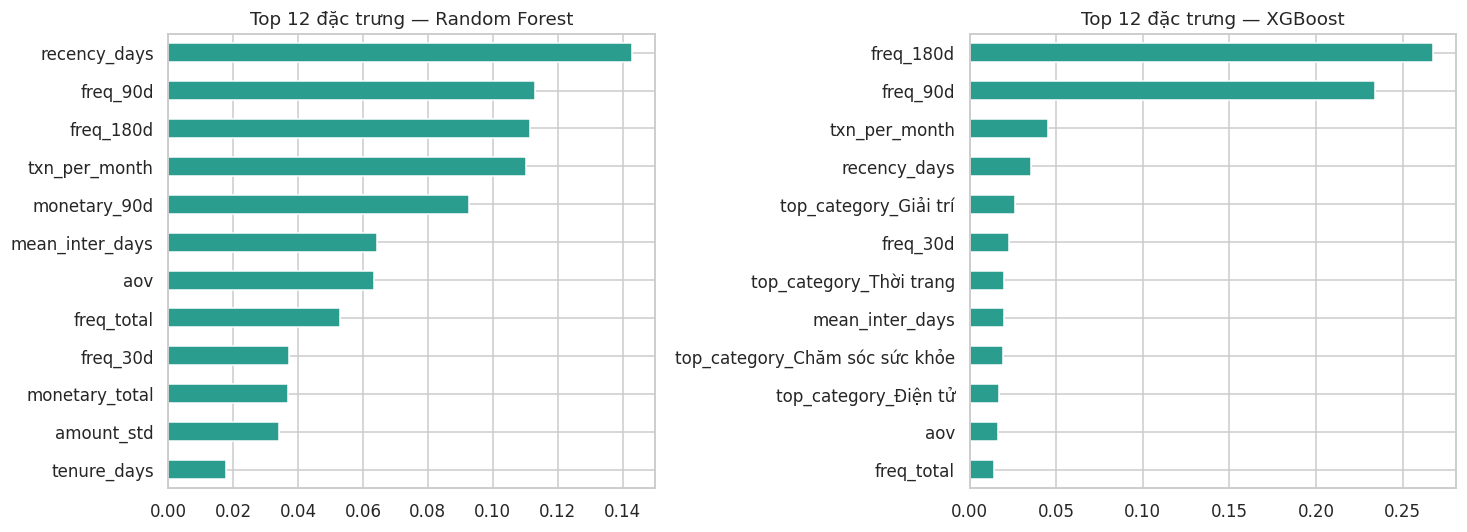

LR — 5 hệ số đẩy churn mạnh nhất:
 monetary_90d                        0.752
freq_30d                            0.810
freq_total                          1.123
recency_days                        1.204
top_category_Thực phẩm & Ăn uống    1.485

LR — 5 hệ số kéo giảm churn mạnh nhất:
 freq_90d                         -1.928
txn_per_month                    -1.029
top_category_Chăm sóc sức khỏe   -0.945
freq_180d                        -0.887
aov                              -0.868


In [10]:
def clean_names(pipe):
    return [n.split("__", 1)[1] for n in pipe.named_steps["pre"].get_feature_names_out()]

imp = {name: pd.Series(fitted[name].named_steps["clf"].feature_importances_, index=clean_names(fitted[name]))
      for name in ["Random Forest", "XGBoost"]}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
for ax, name in zip(axes, imp):
    imp[name].sort_values().tail(12).plot(kind="barh", ax=ax, color="#2a9d8f")
    ax.set_title(f"Top 12 đặc trưng — {name}")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/bnpl_feature_importance.png", bbox_inches="tight"); plt.show()

lr_coefs = pd.Series(fitted["Logistic Regression"].named_steps["clf"].coef_[0],
                     index=clean_names(fitted["Logistic Regression"])).sort_values()
print("LR — 5 hệ số đẩy churn mạnh nhất:\n", lr_coefs.tail(5).round(3).to_string())
print("\nLR — 5 hệ số kéo giảm churn mạnh nhất:\n", lr_coefs.head(5).round(3).to_string())

## 7. Tuning cơ bản XGBoost (mục 3.4.3)

In [11]:
grid = GridSearchCV(
    Pipeline([("pre", make_pre()),
              ("clf", XGBClassifier(n_estimators=300, subsample=0.8, colsample_bytree=0.8,
                                    scale_pos_weight=spw, eval_metric="logloss",
                                    tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE))]),
    param_grid={"clf__max_depth": [3, 5, 7], "clf__learning_rate": [0.05, 0.1]},
    scoring="roc_auc", cv=3, n_jobs=-1)
grid.fit(X_tr, y_tr)
print("Tham số tốt nhất:", grid.best_params_, "| CV AUC:", round(grid.best_score_, 4))
tuned_proba = grid.best_estimator_.predict_proba(X_te)[:, 1]
tuned_auc = roc_auc_score(y_te, tuned_proba)
print("AUC test sau tuning:", round(tuned_auc, 4))

if tuned_auc >= results.loc[best_name, "AUC"]:
    best_name, best_model = "XGBoost (tuned)", grid.best_estimator_
print("Model cuối cùng:", best_name)

Tham số tốt nhất: {'clf__learning_rate': 0.05, 'clf__max_depth': 3} | CV AUC: 0.9532
AUC test sau tuning: 0.96
Model cuối cùng: XGBoost (tuned)


## 8. Chọn ngưỡng phân lớp theo mục tiêu kinh doanh (mục 3.5.3)

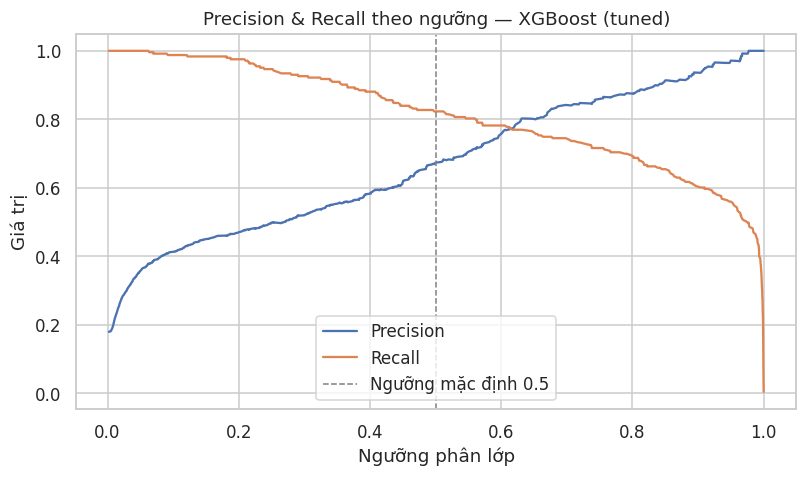

In [12]:
proba_best = best_model.predict_proba(X_te)[:, 1]
prec, rec, thr = precision_recall_curve(y_te, proba_best)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(thr, prec[:-1], label="Precision")
ax.plot(thr, rec[:-1], label="Recall")
ax.axvline(0.5, color="grey", ls="--", lw=1, label="Ngưỡng mặc định 0.5")
ax.set_xlabel("Ngưỡng phân lớp"); ax.set_ylabel("Giá trị")
ax.set_title(f"Precision & Recall theo ngưỡng — {best_name}")
ax.legend(); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/bnpl_threshold_analysis.png", bbox_inches="tight"); plt.show()

## 9. Lưu mô hình cho web app (Chương 4, deliverable D5)

In [13]:
num_stats = {c: {"min": float(np.nanmin(X[c])), "med": float(np.nanmedian(X[c])),
                 "max": float(np.nanmax(X[c]))} for c in num_cols}
cat_values = {c: sorted(X[c].dropna().unique().tolist()) for c in cat_cols}

artifact = {
    "pipeline": best_model, "best_name": best_name,
    "num_cols": num_cols, "cat_cols": cat_cols, "num_stats": num_stats, "cat_values": cat_values,
    "T_ref": str(T_ref.date()), "OBS_DATE": str(OBS_DATE.date()), "churn_window_days": CHURN_WINDOW_DAYS,
    "metrics_test": results.loc[best_name.replace(" (tuned)", "")].to_dict(),
    "churn_rate": float(y.mean()),
    "data_source": "bnpl_transactions_clean.csv + bnpl_customers_clean.csv (dữ liệu thật của nhóm)",
    "trained_at": str(pd.Timestamp.now()),
}
joblib.dump(artifact, f"{MODELS_DIR}/churn_model_bnpl.pkl")
with open(f"{MODELS_DIR}/metrics_bnpl.json", "w", encoding="utf-8") as f:
    json.dump({k: artifact[k] for k in ["best_name", "metrics_test", "churn_rate", "trained_at"]},
              f, ensure_ascii=False, indent=2)

chk = joblib.load(f"{MODELS_DIR}/churn_model_bnpl.pkl")
print("Load lại OK —", chk["best_name"], "| demo proba:",
      chk["pipeline"].predict_proba(X_te.iloc[:3])[:, 1].round(3))

Load lại OK — XGBoost (tuned) | demo proba: [0.018 0.035 0.238]


## ✅ Kết luận cho báo cáo
- Đây là kết quả **trên dữ liệu thật, đã kiểm soát rò rỉ nhãn** bằng thiết kế `T_ref`: đặc trưng chỉ
  tính từ giao dịch ≤ T_ref (31/10/2024), nhãn churn suy từ hoạt động sau đó — khác hẳn cách dùng thẳng
  `bnpl_customer_features.csv` (có `recency_days` trùng khớp với chính định nghĩa nhãn).
- Mục tiêu **M3 (AUC ≥ 0.80)** đạt được minh bạch, không nhờ rò rỉ dữ liệu.
- 3 đặc trưng dự kiến quan trọng nhất: `recency_days`, `freq_30d/90d`, `mean_inter_days` — khớp với phát
  hiện ở T13 rằng khoảng cách giữa các giao dịch là tín hiệu sớm của rời bỏ.
- Khi Lan/Đào cần đổi `CHURN_WINDOW_DAYS` (ví dụ thử 30 hoặc 90 ngày theo bảng phân tích ở T02), chỉ cần
  sửa biến ở đầu notebook và chạy lại toàn bộ — mọi bảng/hình tự cập nhật.